<h4>The 2nd component model - Reinforcement Learning Model</h4>

In [3]:
# !pip install keras
# !pip install tensorflow
# !pip install yfinance
# !pip install tensorflow-cpu

In [4]:
#Import Model Packages for reinforcement learning
from sklearn.preprocessing import StandardScaler
import keras
from keras import layers, models, optimizers
from keras import backend as K
from keras.models import Sequential
from keras.models import load_model
from keras.layers import Dense
from keras.optimizers import Adam
from IPython.core.debugger import set_trace

# Import other general use libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
import datetime
import math
from numpy.random import choice
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from collections import deque
import yfinance as yf
from datetime import date, datetime, timedelta
import statistics
import warnings
warnings.filterwarnings('ignore')

In [5]:
# The data period used to train and test the component models is 2025/1/1 to 2025/12/31.
# The data period used to train and test the combined model is 2023/12/1 to 2024/11/30.
# Below extracted all the data needed first.
endDate = date(2025, 12, 31)
startDate = date(2023, 12, 1)

# For the RL model, it is trying to learn the information hidden in the pattern oif returns, therefore using S&P500 as it is the market index.
stk_tickers = ['^GSPC']

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

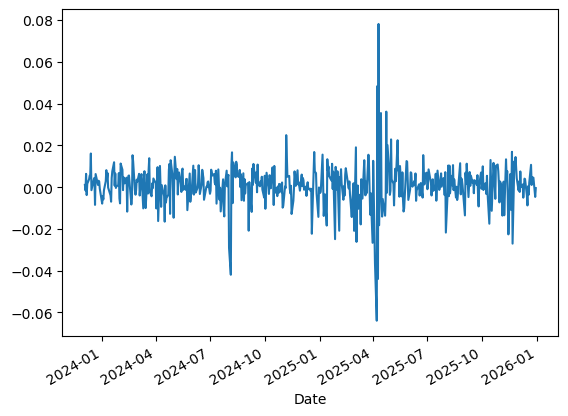

In [6]:
# Getting the finance data
financeData = yf.download(stk_tickers, start = startDate, end = endDate, interval = '1d')
financeData.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
financeData = financeData.dropna()
financeData = financeData.sort_values(by = 'Date', ascending = True)
financeData['prevReturn'] = financeData['Open'].pct_change()
financeData = financeData.dropna()
financeData['prevReturn'].plot()

In [7]:
# getting the data and settings readfy for reinforcement learning component model.
X = financeData[financeData.index >= '2025-01-01']
X = list(X["prevReturn"])
X = [float(x) for x in X]
validation_size = 0.6
# since the characteristics of time series want to be kept, just split the data in between to get the train set and test set.
train_size = int(len(X) * (1 - validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]

# to calulate the profit and rewards for the agent in later sections
price = financeData[financeData.index >= '2025-01-01']
price = list(price["Open"])
price = [float(p) for p in price]
price_train, price_test = price[0:train_size], price[train_size:len(price)]

In [8]:
# the reinforcement learning agent
class Agent:
    def __init__(self, state_size, is_eval = False, model_name = ""):
        self.state_size = state_size
        self.action_size = 2 # sell (hold if not in position), buy (hold if in position already)
        self.memory = deque(maxlen = 1000)
        self.inventory = []
        self.model_name = model_name
        self.is_eval = is_eval
        self.gamma = 0.95 # prioritizes future over immediate
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.95
        if is_eval:
            self.model = load_model(model_name)
            self.epsilon = 0 # no random action at all
        else:
            self.model = self._model()
            self.epsilon = 1 # start with totally random action, then gradually become learnt action

    # Deep Q Learning model which calculate the q-value with given state
    def _model(self):
        model = Sequential()
        model.add(Dense(units = self.state_size, input_dim = self.state_size, activation = "relu"))
        model.add(Dense(units = self.state_size * 4, activation = "relu"))
        model.add(Dense(units = self.state_size * 16, activation = "relu"))
        model.add(Dense(units = self.state_size * 4, activation = "relu"))
        model.add(Dense(units = self.action_size, activation = "linear"))
        model.compile(loss = "mse", optimizer = Adam(learning_rate = 0.001))
        return model

    # if epsilon is low, no random actions
    def act(self, state):
        if not self.is_eval and random.random() <= self.epsilon:
            return random.randrange(self.action_size)
        options = self.model.predict(state)
        return np.argmax(options[0])

    # Replay function to add, sample and evaluate a buffer
    def expReplay(self, batch_size):
        mini_batch = []
        l = len(self.memory)
        for i in range(l - batch_size + 1, l):
            mini_batch.append(self.memory[i])

        # memory during training
        for state, action, reward, next_state, done in mini_batch:
            target = reward
            if not done:
                target = reward + self.gamma * np.amax(self.model.predict(next_state)[0])

            # Q-value of the state
            target_f = self.model.predict(state, verbose = 0)
            # Update the Q table
            target_f[0][action] = target
            self.model.fit(state, target_f, epochs = 1, verbose = 0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [9]:
# Helper Functions

# prints formatted price
def formatPrice(n):
    return ("-$" if n < 0 else "$") + "{0:.2f}".format(abs(n))

# returns an n-day state representation ending at time t
def getState(data, t, n):
    d = t - n + 1
    if d >= 0:
      block = data[d:t]
    else:
      block = -d * [data[0]] + data[0:t]
    return np.array([block])

# Plots the behavior of the output
def plot_behavior(data_input, states_buy, states_sell, profit):
    fig = plt.figure(figsize = (15, 5))
    plt.plot(data_input, color = 'r', lw = 2.)
    plt.plot(data_input, '^', markersize = 10, color = 'm', label = 'Buy', markevery = states_buy)
    plt.plot(data_input, 'v', markersize = 10, color = 'k', label = 'Sell', markevery = states_sell)
    plt.title('Total Profit: %f' % (profit))
    plt.legend()
    plt.show()

Running episode 0/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27

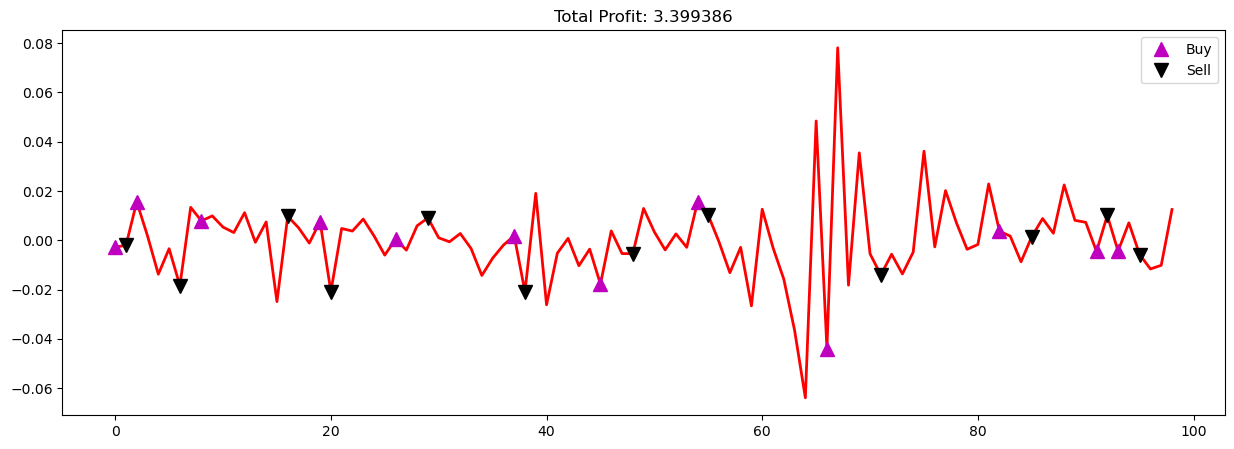

Running episode 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26

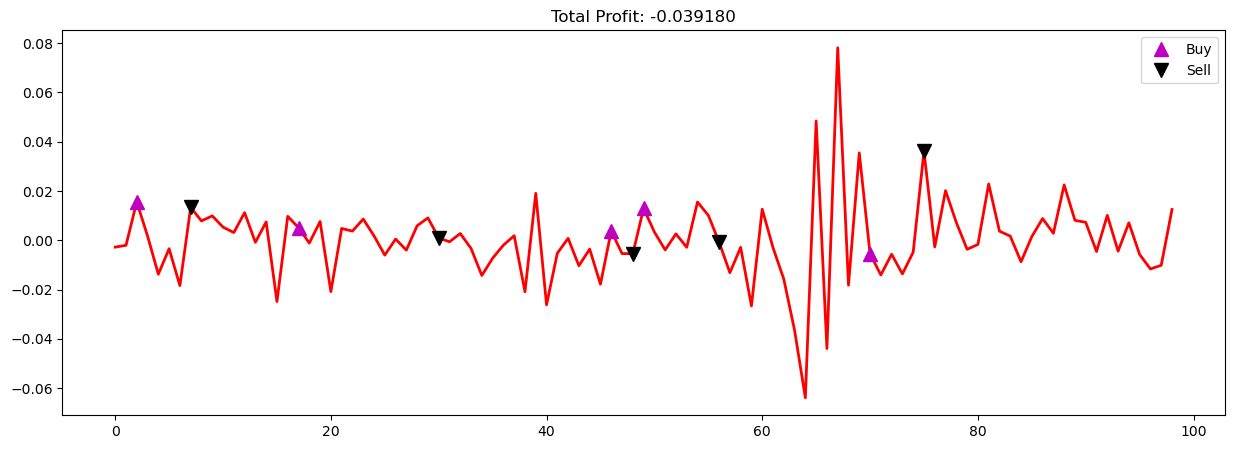

Running episode 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26

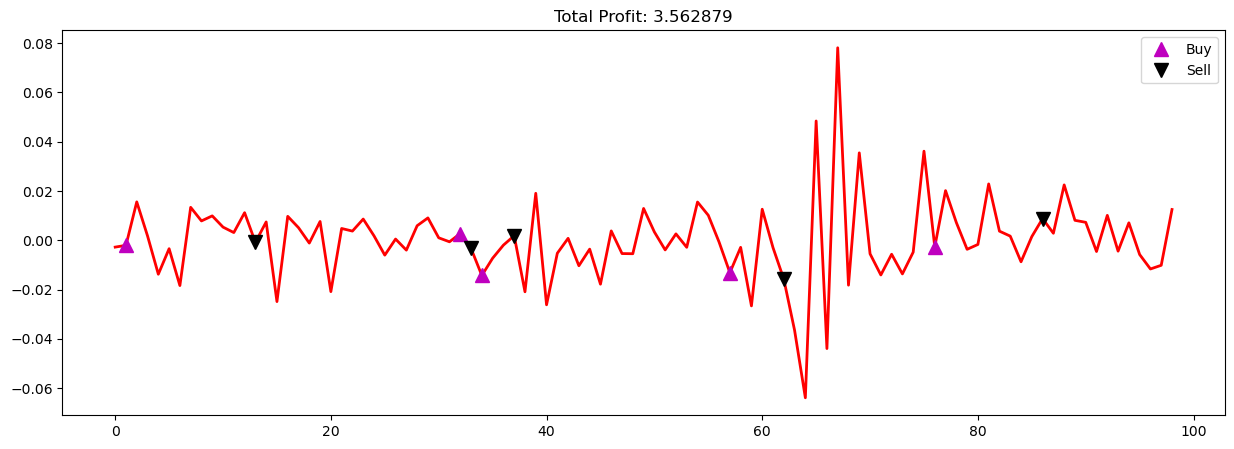

Running episode 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27

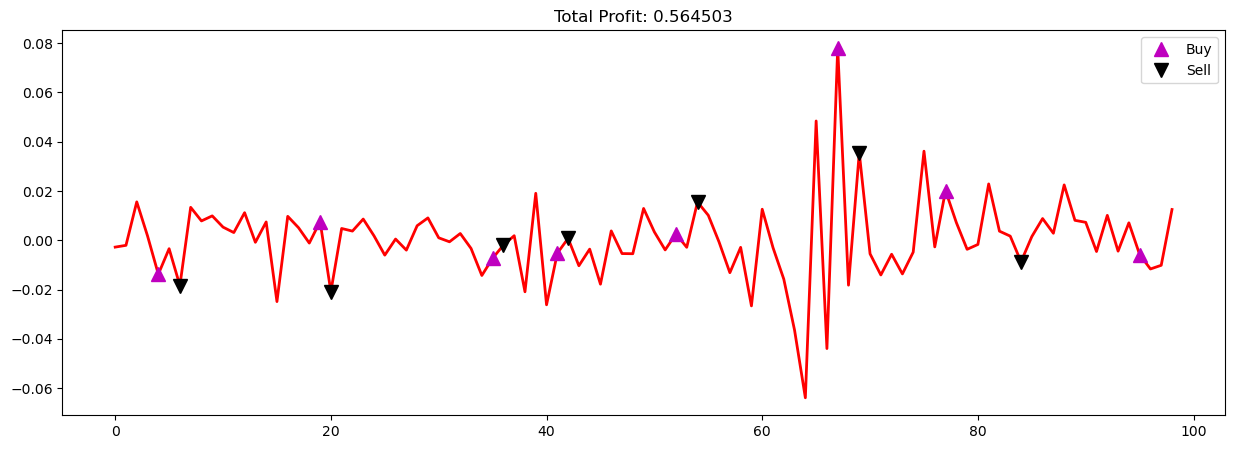

In [10]:
# start training the agent
window_size = 10
agent = Agent(window_size)
data = X_train
l = len(data) - 1
batch_size = 8
episode_count = 3

for e in range(episode_count + 1):
    print("Running episode " + str(e) + "/" + str(episode_count))
    state = getState(data, 0, window_size + 1)
    startMoney = 100
    total_profit = 0
    agent.inventory = []
    states_sell = []
    states_buy = []
    for t in range(l):
        action = agent.act(state)
        next_state = getState(data, t + 1, window_size + 1)
        reward = 0

        # buy
        if action == 1:
            if len(agent.inventory) == 0:
                agent.inventory.append(price_train[t])
                states_buy.append(t)
                # print('buy')
            else: # hold if in position already
                pass
                # print('buy(hold)')
        # sell
        elif action == 0:
            if len(agent.inventory) > 0:
                bought_price = agent.inventory.pop(0)
                profit =  (startMoney + total_profit) * ((price_train[t] - bought_price) / bought_price)
                total_profit += profit
                states_sell.append(t)
                reward = max(profit, 0)
                # print('sell')
            else: # hold if not in position already
                pass
                # print('sell(hold)')

        done = True if t >= l - 1 else False
        agent.memory.append((state, action, reward, next_state, done))
        state = next_state
        if len(agent.memory) > batch_size:
            agent.expReplay(batch_size)

        # plot the graph
        if done:
            print("--------------------------------")
            print("Total Profit: " + formatPrice(total_profit))
            plot_behavior(data, states_buy, states_sell, total_profit)
            
    if e < episode_count:
        # save each model for later to use in testing
        agent.model.save("RL_model_ep" + str(e) + ".keras")
    else:
        agent.model.save("RL_model_final.keras")

In [11]:
# Deep Q-Learning Model summary
print(agent.model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 160)            │         6,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         6,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            82 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,898 (159.76 KB)

 Trainable params: 13,632 (53.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,266 (106.51 KB)

None


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Buy: $5925.54
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Sell: $6009.91
^ profit: $1.42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1

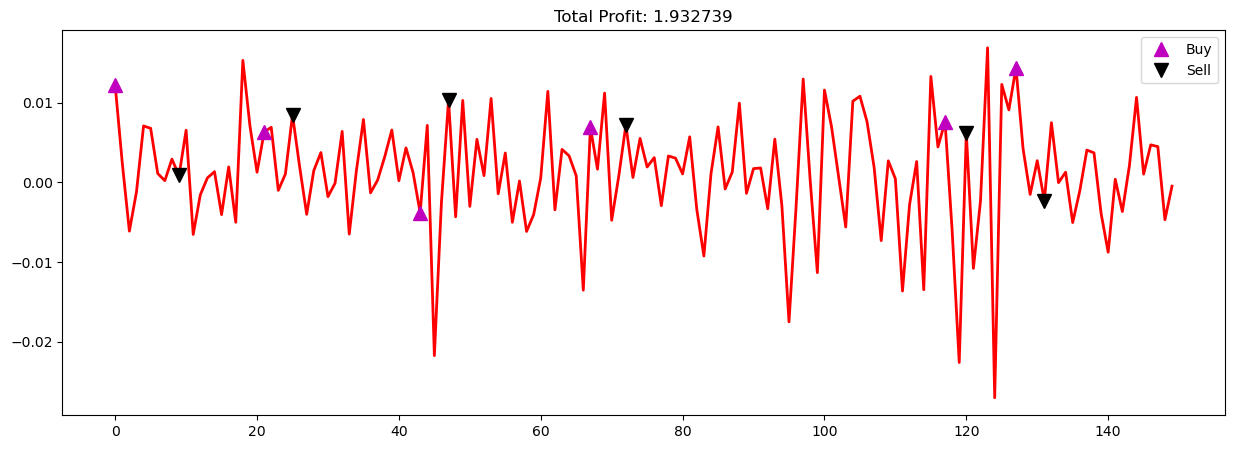

In [12]:
# after the agent is trained, testing the agent
# we build the runAgent function first
def runAgent(data, dataPrice, model_name, showLog = False):
    window_size = 10
    batch_size = 8
    # load the agent
    is_eval = True
    agent = Agent(window_size, is_eval, model_name)
    l = len(data) - 1
    state = getState(data, 0, window_size + 1)
    startMoney = 100
    total_profit = 0
    done = False
    states_sell = []
    states_buy = []
    states_sell_signal = []
    states_buy_signal = []
    agent.inventory = []
    
    for t in range(l):
        action = agent.act(state)
        next_state = getState(data, t + 1, window_size + 1)
        reward = 0

        # buy
        if action == 1:
            if len(agent.inventory) == 0:
                agent.inventory.append(dataPrice[t])
                states_buy.append(t)
                states_buy_signal.append(t)
                if showLog:
                    print("Buy: " + formatPrice(dataPrice[t])) 
            else: # hold if in position already
                states_buy_signal.append(t)
                print('buy(hold)')
        # sell
        elif action == 0:
            if len(agent.inventory) > 0:
                bought_price = agent.inventory.pop(0)
                profit =  (startMoney + total_profit) * ((dataPrice[t] - bought_price) / bought_price)
                total_profit += profit
                states_sell.append(t)
                states_sell_signal.append(t)
                reward = max(profit, 0)
                if showLog:
                    print("Sell: " + formatPrice(dataPrice[t]))
                    print("^ profit: " + formatPrice(profit))
            else: # hold if not in position already
                states_sell_signal.append(t)
                # print('sell(hold)')

        done = True if t >= l - 1 else False
        agent.memory.append((state, action, reward, next_state, done))
        state = next_state
        if len(agent.memory) > batch_size:
            agent.expReplay(batch_size)

    return total_profit, states_buy, states_sell, states_buy_signal, states_sell_signal

# then we start testing
data = X_test
dataPrice = price_test
model_name = "RL_model_final.keras"
total_profit, states_buy, states_sell, states_buy_signal, states_sell_signal = runAgent(data, dataPrice, model_name, True) 
print("------------------------------------------")
print("Total Profit: " + formatPrice(total_profit))
plot_behavior(data, states_buy, states_sell, total_profit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Buy: $4564.37
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
buy(hold)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Sell: $4714.23
^ profit: $3.28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1

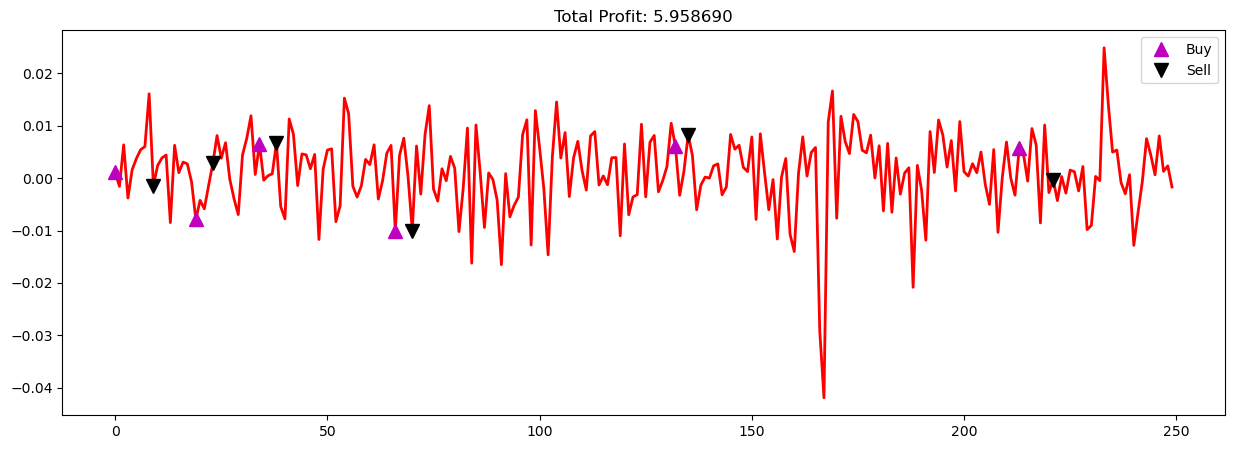

In [13]:
# After testing the model can generate profit, use the agent to generate data for the training and testing of the combined model. 
financeData = financeData[financeData.index <= '2024-11-30']
data = list(financeData["prevReturn"])
data = [float(d) for d in data]
dataPrice = list(financeData["Open"])
dataPrice = [float(p) for p in dataPrice]
model_name = "RL_model_final.keras"
total_profit, states_buy, states_sell, states_buy_signal, states_sell_signal = runAgent(data, dataPrice, model_name, True) 
print("------------------------------------------")
print("Total Profit: " + formatPrice(total_profit))
plot_behavior(data, states_buy, states_sell, total_profit)

In [14]:
# convert the buy signal and match with the original financeData
buySignalList = []
for i in range(len(data)):
    if i in states_buy_signal:
        buySignalList.append(1)
    elif i in states_sell_signal:
        buySignalList.append(0)
temp_df = pd.DataFrame(buySignalList, columns = ['signal_RL'])
financeData = financeData.reset_index()
temp_df = pd.merge(financeData, temp_df, left_index = True, right_index = True, how = 'inner')
RLData = temp_df[['Date', 'signal_RL']]
RLData.to_csv('RL_Data.csv')

In [15]:
# below show how to use the reinforcement learning agent on latest data

# get latest finance data
window_size = 10
endDate = date.today()
startDate = endDate - timedelta(days = window_size * 2) # just to ensure enough data if some days is not trading day
financeData = yf.download(stk_tickers, start = startDate, end = endDate, interval = '1d')
financeData.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
financeData = financeData.dropna()
financeData = financeData.sort_values(by = 'Date', ascending = True)
financeData['prevReturn'] = financeData['Open'].pct_change()
financeData = financeData.dropna()
financeData = financeData.tail(window_size)

# load the RL model previously saved
model_RL_loaded = load_model('RL_model_final.keras')
X = list(financeData["prevReturn"])
X = np.array([[float(x) for x in X]])
indicatorValue = np.argmax(model_RL_loaded.predict(X)[0])
print('RL signal on latest finance data: %.0f' % (indicatorValue))

[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
RL signal on latest finance data: 1
